# Notebook: `08. Análises`
---

## Descrição: 
Esse notebook realiza as análises finais para a respostas das perguntas dee negócio do MVP.

Define o catálogo e schema usado.

In [0]:
%sql
USE mvp.gold

Perguntas:
- 1 - Como tem evoluído a participação do marketshare dos serviços de taxi legado frente aos serviços de corrida por aplicativo (For Hire Services)? Qual é o marketshare dos taxis no ano atual, 2026, e qual ano foi o ponto de inflexão quando as corridas do tipo "For Hire Services" passaram a dominar?
- 2 - Qual a taxa de corridas disputadas e nulas para Taxis Verdes e Amarelos nos últimos 2 anos? Esse percentual tem aumentado ou diminuido?
- 3 - Qual o método de pagamento predominante para os taxis verdes e amarelos nos últimos anos? Como essa distribuição mudou na última década?
- 4 - Existem registros de corridas suspeitas realizadas por Taxis Amarelos e Verdes? Por corrida suspeita, entende-se como aquelas que não estão de acordo com a >legislação de Taxis da cidade: Táxis amarelos e verdes não podem buscar passageiros fora da cidade de Nova Iorque, e Taxis Verdes não podem: Buscar passageiros de >Aeroportos exceto quando a corrida tem tarifa pré combinada, buscar passageiros em zonas exclusivas de taxis amarelos.
- 5 - Quais serviços de corrida por aplicativo ou taxi dominam em cada distrito? Quais são os 5 principais bairros de pico para embarque e desembarque durante o ano, considerando dias úteis e não úteis de 2025 e 2026?
- 6 - Quais são os horários de pico, para embarque e desembarque, por distrito, em dias úteis e não úteis?
- 7 - Como a remuneração total do motorista de serviços de corrida por aplicativo tem acompanhado a inflação geral desde 2019?
- 8 - Como as tarifas base ao passageiro (sem incluir impostos, gorjetas e taxas) tem acompanhado a inflação geral americana, e a inflação especifica do segmento de transportes? As regulamentações do setor taxista fazem com que ela tenha sofrido menos ou mais reajustes na inflação com relação a corridas por aplicativo?

1 - Como tem evoluído a participação do marketshare dos serviços de taxi legado frente aos serviços de corrida por aplicativo (For Hire Services)? Qual é o marketshare dos taxis no ano atual, 2026, e qual ano foi o ponto de inflexão quando as corridas do tipo "For Hire Services" passaram a dominar?

In [0]:
%sql
WITH base AS (
  SELECT
    c.ano,
    v.categoria,
    SUM(f.Qtd_Viagens) AS qtd_corridas
  FROM fato_corrida_mensal f
  JOIN dim_calendario c ON f.Data = c.Data
  JOIN dim_tipo_veiculo v ON f.ID_Veiculo = v.ID_Veiculo
  GROUP BY c.ano, v.categoria
)
SELECT
  ano,
  categoria,
  qtd_corridas,
  ROUND(100.0 * qtd_corridas / SUM(qtd_corridas) OVER (PARTITION BY ano), 2) AS pct_ano
FROM base
ORDER BY ano, categoria

ano,categoria,qtd_corridas,pct_ano
2016,For Hire Service,92660506,39.07
2016,Taxi,144525747,60.93
2017,For Hire Service,158898132,56.46
2017,Taxi,122521238,43.54
2018,For Hire Service,210706163,65.89
2018,Taxi,109058606,34.11
2019,For Hire Service,248467859,73.87
2019,Taxi,87882128,26.13
2020,For Hire Service,140031716,85.16
2020,Taxi,24409317,14.84


Databricks visualization. Run in Databricks to view.

Pode se observar que o segmento "For Hire Services" já representava em 2016 39,1% do mercado de transportes pagos dentro da cidade. Esse segmento cresceu continuamente, deslocando a participação dos táxis tradicionais de forma acelerada até meados de 2020, quando amaduresceu com 85,2% de marketshare. A partir de então o segmento cresceu lentamente, chegando a 89,3% de participação do mercado em 2026.

O ponto de inflexão da dominância dos tradicionais táxis amarelos e verdes foi em meados de 2017, mais especificamente em janeiro, quando atingiu o marco de 50,37% de mercado.

Esse fenômeno mostra que os serviços de transporte por aplicativo de alto volume oferecem algum tipo de vantagem ao passageiro que os táxis não conseguiram competir, podendo ser desde a qualidade do veículo, valor cobrado ao consumidor, ou praticidade de uso, demandando apenas demandar uma viagem via celular.

Marketshare em 2026

In [0]:
%sql
WITH base AS (
  SELECT
    c.ano,
    v.categoria,
    SUM(f.Qtd_Viagens) AS qtd_corridas
  FROM fato_corrida_mensal f
  JOIN dim_calendario c ON f.Data = c.Data
  JOIN dim_tipo_veiculo v ON f.ID_Veiculo = v.ID_Veiculo
  GROUP BY c.ano, v.categoria
  HAVING c.ano = 2026
)
SELECT
  ano,
  categoria,
  ROUND(100.0 * qtd_corridas / SUM(qtd_corridas) OVER (PARTITION BY ano), 2) AS pct_ano
FROM base
ORDER BY ano, categoria

ano,categoria,pct_ano
2026,For Hire Service,89.32
2026,Taxi,10.68


Databricks visualization. Run in Databricks to view.

Mês exato em que o segmento "For Hire Service" representou mais de 50% das viagens contratadas na cidade.

In [0]:
%sql
WITH base AS (
  SELECT
    c.ano,
    c.Nr_Mes,
    v.categoria,
    SUM(f.Qtd_Viagens) AS qtd_corridas
  FROM fato_corrida_mensal f
  JOIN dim_calendario c ON f.Data = c.Data
  JOIN dim_tipo_veiculo v ON f.ID_Veiculo = v.ID_Veiculo
  GROUP BY c.ano, c.Nr_Mes, v.categoria
),
perc AS (
SELECT
  ano,
  Nr_Mes,
  categoria,
  ROUND(100.0 * qtd_corridas / SUM(qtd_corridas) OVER (PARTITION BY ano, Nr_Mes), 2) AS pct_ano
FROM base
ORDER BY ano, Nr_Mes, categoria
)
SELECT ano, Nr_Mes, categoria, pct_ano
FROM perc
WHERE categoria = 'For Hire Service' AND pct_ano >= 50
ORDER BY ano
LIMIT 1

ano,Nr_Mes,categoria,pct_ano
2017,1,For Hire Service,50.37


Em 2026, o segmento de taxi legado (taxis amarelos + taxis verdes) representam apenas 10,7% do marketshare de corridas em nova iorque. O segmento for hire service compreende 89,3% do mercado.
E o segmento passou a representar maioria a partir de janeiro de 2017, com 50,37% de participação.

- 2 - Qual a taxa de corridas disputadas e nulas para Taxis Verdes e Amarelos nos últimos 4 anos? Esse percentual tem aumentado ou diminuido?

In [0]:
%sql
WITH base AS (
    SELECT
        c.ano,
        v.Tipo_Veiculo,
        SUM(f.Qtd_Viagens) AS Qtd_Viagens,
        SUM(
            CASE WHEN f.Metodo_Pagamento NOT IN ('Disputado') THEN 0
            ELSE f.Qtd_Viagens
            END
        ) AS Qtd_Disputas,
        SUM(
            CASE WHEN f.Metodo_Pagamento NOT IN ('Viagem anulada') THEN 0
            ELSE f.Qtd_Viagens
            END
        ) AS Qtd_Anulada,
        SUM(
            CASE WHEN f.Metodo_Pagamento NOT IN ('Sem cobrança') THEN 0
            ELSE f.Qtd_Viagens
            END
        ) AS Qtd_Sem_Cobranca
    FROM fato_corrida_mensal f
    JOIN dim_calendario c
        ON f.Data = c.Data
    JOIN dim_tipo_veiculo v
        ON f.ID_Veiculo = v.ID_Veiculo

    WHERE c.Ano >= 2023
        AND v.Categoria = 'Taxi'
    GROUP BY c.ano, v.Tipo_Veiculo
    ORDER BY c.ano, v.Tipo_Veiculo
)

SELECT
    ano,
    Tipo_Veiculo,
    ROUND( (SUM(Qtd_Disputas) / SUM(Qtd_Viagens)) * 100, 2) AS Perc_Disputas,
    ROUND( (SUM(Qtd_Anulada) / SUM(Qtd_Viagens)) * 100, 2) AS Perc_Anulada,
    ROUND( (SUM(Qtd_Sem_Cobranca) / SUM(Qtd_Viagens)) * 100, 2) AS Perc_Sem_Cobranca
FROM base
    GROUP BY ano, Tipo_Veiculo
ORDER BY ano, Tipo_Veiculo
--SELECT * FROM base

ano,Tipo_Veiculo,Perc_Disputas,Perc_Anulada,Perc_Sem_Cobranca
2023,Taxi Amarelo,0.63,0.0,0.35
2023,Taxi Verde,0.09,0.0,0.33
2024,Taxi Amarelo,1.01,0.0,0.4
2024,Taxi Verde,0.08,0.0,0.27
2025,Taxi Amarelo,1.43,0.0,0.42
2025,Taxi Verde,0.07,0.0,0.25
2026,Taxi Amarelo,0.59,0.0,0.26
2026,Taxi Verde,0.09,0.0,0.2


Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

Observa-se que, nos últimos quatro anos, as taxas de corridas disputadas, anuladas e sem cobrança representaram um percentual baixo (< 2%) do total de corridas dos táxis amarelos e verdes.

Não foram registradas corridas anuladas no período. No entanto, isso pode ser efeito dos filtros de qualidade aplicados na camada `silver`, como a remoção de corridas com início e fim desconhecidos, uma interação de filtros que não foi explorada na análise de dados.

A taxa de corridas disputadas permaneceu estável para os táxis verdes (0,07% a 0,09% do total), enquanto para os táxis amarelos aumentou de 0,63% em 2023 para 1,43% em 2025. No ano atual, esse percentual caiu para 0,59%, o que indica que os provedores de serviço do táxi amarelo podem ter realizado ajustes operacionais para melhorar o indicador.

Quanto às corridas sem cobrança, tanto os táxis verdes quanto os amarelos apresentaram leve queda no período. Os táxis amarelos reduziram a incidência de 0,35% em 2023 para 0,26% em 2026, enquanto os verdes reduziram de 0,33% para 0,20% no mesmo intervalo.

- 3 - Qual o método de pagamento predominante para os taxis verdes e amarelos nos últimos anos? Como essa distribuição mudou na última década?

Métodos de pagamento para táxis amarelos

In [0]:
%sql
WITH base AS (
  SELECT
    c.ano,
    f.Metodo_Pagamento,
    v.Tipo_Veiculo,
    SUM(f.Qtd_Viagens) AS qtd_corridas
  FROM fato_corrida_mensal f
  JOIN dim_calendario c ON f.Data = c.Data
  JOIN dim_tipo_veiculo v ON f.ID_Veiculo = v.ID_Veiculo
    WHERE v.Tipo_Veiculo = 'Taxi Amarelo'
    AND f.Metodo_Pagamento NOT IN ('Disputado', 'Viagem anulada', 'Sem cobrança', 'Desconhecido')
  GROUP BY c.ano, f.Metodo_Pagamento, v.Tipo_Veiculo
)
SELECT
  ano,
  Metodo_Pagamento,
  qtd_corridas,
  Tipo_Veiculo,
  ROUND(100.0 * qtd_corridas / SUM(qtd_corridas) OVER (PARTITION BY ano), 2) AS pct_ano
FROM base
ORDER BY ano, Metodo_Pagamento, Tipo_Veiculo

ano,Metodo_Pagamento,qtd_corridas,Tipo_Veiculo,pct_ano
2016,Cartão de crédito,84783898,Taxi Amarelo,66.27
2016,Dinheiro,43157505,Taxi Amarelo,33.73
2017,Cartão de crédito,74904588,Taxi Amarelo,67.83
2017,Dinheiro,35525965,Taxi Amarelo,32.17
2018,Cartão de crédito,70036472,Taxi Amarelo,70.09
2018,Dinheiro,29892683,Taxi Amarelo,29.91
2019,Cartão de crédito,59734205,Taxi Amarelo,72.81
2019,Dinheiro,22305744,Taxi Amarelo,27.19
2020,Cartão de crédito,17163167,Taxi Amarelo,74.14
2020,Dinheiro,5985674,Taxi Amarelo,25.86


Databricks visualization. Run in Databricks to view.

Métodos de pagamento para táxis verdes

In [0]:
%sql
WITH base AS (
  SELECT
    c.ano,
    f.Metodo_Pagamento,
    v.Tipo_Veiculo,
    SUM(f.Qtd_Viagens) AS qtd_corridas
  FROM fato_corrida_mensal f
  JOIN dim_calendario c ON f.Data = c.Data
  JOIN dim_tipo_veiculo v ON f.ID_Veiculo = v.ID_Veiculo
    WHERE v.Tipo_Veiculo = 'Taxi Verde'
    AND f.Metodo_Pagamento NOT IN ('Disputado', 'Viagem anulada', 'Sem cobrança', 'Desconhecido')
  GROUP BY c.ano, f.Metodo_Pagamento, v.Tipo_Veiculo
)
SELECT
  ano,
  Metodo_Pagamento,
  qtd_corridas,
  Tipo_Veiculo,
  ROUND(100.0 * qtd_corridas / SUM(qtd_corridas) OVER (PARTITION BY ano), 2) AS pct_ano
FROM base
ORDER BY ano, Metodo_Pagamento, Tipo_Veiculo

ano,Metodo_Pagamento,qtd_corridas,Tipo_Veiculo,pct_ano
2016,Cartão de crédito,7980861,Taxi Verde,50.00
2016,Dinheiro,7979646,Taxi Verde,50.00
2017,Cartão de crédito,5821864,Taxi Verde,50.83
2017,Dinheiro,5632698,Taxi Verde,49.17
2018,Cartão de crédito,4926671,Taxi Verde,57.36
2018,Dinheiro,3662422,Taxi Verde,42.64
2019,Cartão de crédito,3111500,Taxi Verde,57.43
2019,Dinheiro,2306129,Taxi Verde,42.57
2020,Cartão de crédito,613814,Taxi Verde,54.43
2020,Dinheiro,513804,Taxi Verde,45.57


Databricks visualization. Run in Databricks to view.

Para os táxis amarelos, o cartão de crédito é a forma predominante de pagamento desde 2016, tendo crescido continuamente desde então até representar 88,5% do total de meios de pagamento, sem considerar as corridas disputadas, anuladas e desconhecidas.

Nos táxis verdes, a predominância do cartão de crédito é mais recente: até meados de 2020, a participação do cartão e a do dinheiro eram aproximadamente iguais, e foi a partir de 2021 que o cartão passou a crescer continuamente. O dinheiro ainda corresponde a 22,8% das transações, o que sugere diferenças de perfil entre os passageiros de Manhattan, onde predomina o táxi amarelo, e os dos demais distritos, onde operam os táxis verdes.

4 - Existem registros de corridas suspeitas realizadas por Taxis Amarelos e Verdes? Por corrida suspeita, entende-se como aquelas que não estão de acordo com a >legislação de Taxis da cidade: Táxis amarelos e verdes não podem buscar passageiros fora da cidade de Nova Iorque, e Taxis Verdes não podem: Buscar passageiros de >Aeroportos exceto quando a corrida tem tarifa pré combinada, buscar passageiros em zonas exclusivas de taxis amarelos.

In [0]:
%sql
SELECT 
    f.Provedor,
    COUNT(*) AS Total_Nao_Comformidades
    FROM fato_corridas_suspeitas f
    LEFT JOIN dim_calendario c
        ON f.Data_Embarque = c.Data
    WHERE c.Ano >= 2024

    GROUP BY f.Provedor

Provedor,Total_Nao_Comformidades
"Curb Mobility, LLC",95575
"Creative Mobile Technologies, LLC",9300


In [0]:
%sql
SELECT 
    f.Motivo_Irregularidade,
    COUNT(*) AS Total_Nao_Comformidades
    FROM fato_corridas_suspeitas f
    LEFT JOIN dim_calendario c
        ON f.Data_Embarque = c.Data
    WHERE c.Ano >= 2024

    GROUP BY f.Motivo_Irregularidade

Motivo_Irregularidade,Total_Nao_Comformidades
Embarque Fora de Nova Iorque,12261
Embarque em zona de taxis amarelos,92100
Embarque em Aeroporto não negociado,390


In [0]:
%sql
SELECT 
        f.Provedor,
        f.Motivo_Irregularidade,
        f.Data_Embarque,
        f.Hora_Destino,
        f.Hora_Embarque,
        f.Hora_Destino,
        v.Tipo_Veiculo,
        z.Zona AS Zona_Embarque,
        z1.Zona AS Zona_Destino,
        f.Metodo_Pagamento,
        f.Tipo_Tarifa
    FROM fato_corridas_suspeitas f
    LEFT JOIN dim_calendario c
        ON f.Data_Embarque = c.Data
    LEFT JOIN dim_tipo_veiculo v
        ON f.ID_Veiculo = v.ID_Veiculo
    LEFT JOIN dim_zonas_de_taxi z
        ON f.ID_Embarque = z.IDLocal
    LEFT JOIN dim_zonas_de_taxi z1
        ON f.ID_Destino = z1.IDLocal
    WHERE c.Ano >= 2024

Provedor,Motivo_Irregularidade,Data_Embarque,Hora_Destino,Hora_Embarque,Hora_Destino,Tipo_Veiculo,Zona_Embarque,Zona_Destino,Metodo_Pagamento,Tipo_Tarifa
"Curb Mobility, LLC",Embarque em zona de taxis amarelos,2026-06-01,8,7,8,Taxi Verde,Bloomingdale,Newark Airport,Cartão de crédito,Newark
"Curb Mobility, LLC",Embarque em zona de taxis amarelos,2026-06-01,8,8,8,Taxi Verde,Bloomingdale,Upper East Side South,Cartão de crédito,Taxa padrão
"Curb Mobility, LLC",Embarque em zona de taxis amarelos,2026-06-01,9,8,9,Taxi Verde,Central Park,Midtown East,Cartão de crédito,Taxa padrão
"Curb Mobility, LLC",Embarque em zona de taxis amarelos,2026-06-01,8,8,8,Taxi Verde,Upper East Side North,Upper East Side North,Cartão de crédito,Taxa padrão
"Curb Mobility, LLC",Embarque em zona de taxis amarelos,2026-06-01,9,9,9,Taxi Verde,Central Park,Upper East Side North,Cartão de crédito,Taxa padrão
"Curb Mobility, LLC",Embarque em zona de taxis amarelos,2026-06-01,9,9,9,Taxi Verde,Central Park,Lenox Hill East,Dinheiro,Taxa padrão
"Curb Mobility, LLC",Embarque em zona de taxis amarelos,2026-06-01,9,9,9,Taxi Verde,Upper East Side North,Upper East Side North,Cartão de crédito,Taxa padrão
"Curb Mobility, LLC",Embarque em zona de taxis amarelos,2026-06-01,11,10,11,Taxi Verde,Central Park,Clinton Hill,Cartão de crédito,Taxa padrão
"Curb Mobility, LLC",Embarque em zona de taxis amarelos,2026-06-01,10,10,10,Taxi Verde,Central Park,Upper East Side North,Dinheiro,Taxa padrão
"Curb Mobility, LLC",Embarque em zona de taxis amarelos,2026-06-01,10,10,10,Taxi Verde,Upper East Side North,Yorkville East,Cartão de crédito,Taxa padrão


A empresa com maior incidência de irregularidades é a Curb Mobility, LLC, com 95.575 incidentes nos últimos três anos. Embora esse número seja significativamente superior ao da Creative Mobile Technologies, não é possível saber se a diferença decorre de uma maior irregularidade dessa empresa ou simplesmente de ela atender a uma quantidade maior de corridas de táxi.

De toda forma, existem de fato não conformidades e, entre as duas empresas, o principal motivo está relacionado ao embarque de passageiros por táxis verdes em zonas de atendimento exclusivo para táxis amarelos, o que é vetado pelos regulamentos da TLC.

Em seguida, o embarque de passageiros fora da cidade de Nova Iorque também ocorre com alta frequência. Trata-se de outra não conformidade, uma vez que a TLC não possui jurisdição para regulamentar serviços de *street hail* e *livery* fora da cidade. Vale notar que o desembarque fora da cidade é permitido; apenas o embarque é vetado.

A não conformidade de táxis verdes realizarem embarque em aeroportos sem tarifa negociada ocorreu apenas 390 vezes desde 2024. Isso sugere que essa infração é mais fiscalizada, ou que ela não gera vantagem direta ao motorista, ao contrário do embarque em zonas exclusivas de táxis amarelos, que pode ocorrer, por exemplo, quando o motorista já está no local desembarcando outro passageiro.

A existência desses registros aponta oportunidades de melhoria no *compliance* das empresas prestadoras desses serviços aos seus motoristas, no rastreamento de veículos e motoristas e na supervisão da TLC sobre as operadoras credenciadas.

5 - Quais serviços de corrida por aplicativo ou taxi dominam em cada distrito? Quais são os 5 principais bairros de pico para embarque e desembarque durante o ano, considerando dias úteis e não úteis de 2025 e 2026?

In [0]:
%sql
WITH base AS (
    SELECT
        z.Distrito,
        v.Tipo_Veiculo,
        SUM(f.Qtd_Viagens) AS Qtd_Viagens
    FROM fato_corrida_mensal f
    JOIN dim_zonas_de_taxi z ON f.ID_Embarque = z.IDLocal
    JOIN dim_tipo_veiculo v ON f.ID_Veiculo = v.ID_Veiculo
    JOIN dim_calendario c ON c.Data = f.Data
    WHERE c.Ano >= 2025

    GROUP BY z.Distrito, v.Tipo_Veiculo
)
SELECT
    Distrito,
    Tipo_Veiculo,
    Qtd_Viagens,
    ROUND(100.0 * Qtd_Viagens / SUM(Qtd_Viagens) OVER (PARTITION BY Distrito), 2) AS Pct_Borough
FROM base
ORDER BY Distrito, Tipo_Veiculo

Distrito,Tipo_Veiculo,Qtd_Viagens,Pct_Borough
Bronx,Lyft,11948481,25.44
Bronx,Taxi Amarelo,233211,0.50
Bronx,Taxi Verde,5518,0.01
Bronx,Uber,34775627,74.05
Brooklyn,Lyft,27835305,28.98
Brooklyn,Taxi Amarelo,710006,0.74
Brooklyn,Taxi Verde,92521,0.10
Brooklyn,Uber,67413575,70.18
EWR,Taxi Amarelo,428,97.49
EWR,Uber,11,2.51


Databricks visualization. Run in Databricks to view.

Em praticamente todos os distritos, o provedor dominante de viagens é a Uber, exceto para o aeroporto internacional Newark Liberty, onde os taxis amarelos ainda predominam, com 97,49% dos registros de embarque. Nos demais distritos da cidade, apenas Manhattan possuí os taxis amarelos como o segundo provedor mais comum, lugar esse tomado pela Lyft, outro provedor de corridas por aplicativo.

In [0]:
%sql
WITH base_Embarque AS (
    SELECT
        c.Fl_Dia_Util,
        z.Zona AS Bairro,
        SUM(f.Qtd_Viagens) AS Qtd_Viagens
    FROM fato_demanda_horaria f
    JOIN dim_calendario c ON f.Data_Embarque = c.Data
    JOIN dim_zonas_de_taxi z ON f.ID_Embarque = z.IDLocal
    WHERE c.Ano >= 2025
    GROUP BY c.Fl_Dia_Util, z.Zona
),
rank_Embarque AS (
    SELECT
        *,
        ROW_NUMBER() OVER (PARTITION BY Fl_Dia_Util ORDER BY Qtd_Viagens DESC) AS Rank_Embarque
    FROM base_Embarque
)
SELECT * FROM rank_Embarque WHERE Rank_Embarque <= 5
ORDER BY Fl_Dia_Util, Rank_Embarque

Fl_Dia_Util,Bairro,Qtd_Viagens,Rank_Embarque
false,JFK Airport,2856577,1
false,LaGuardia Airport,2475494,2
false,East Village,2145526,3
false,Bushwick South,1750290,4
false,Crown Heights North,1745603,5
true,LaGuardia Airport,6441792,1
true,JFK Airport,5699941,2
true,Midtown Center,4053026,3
true,Upper East Side South,3491665,4
true,Times Sq/Theatre District,3304026,5


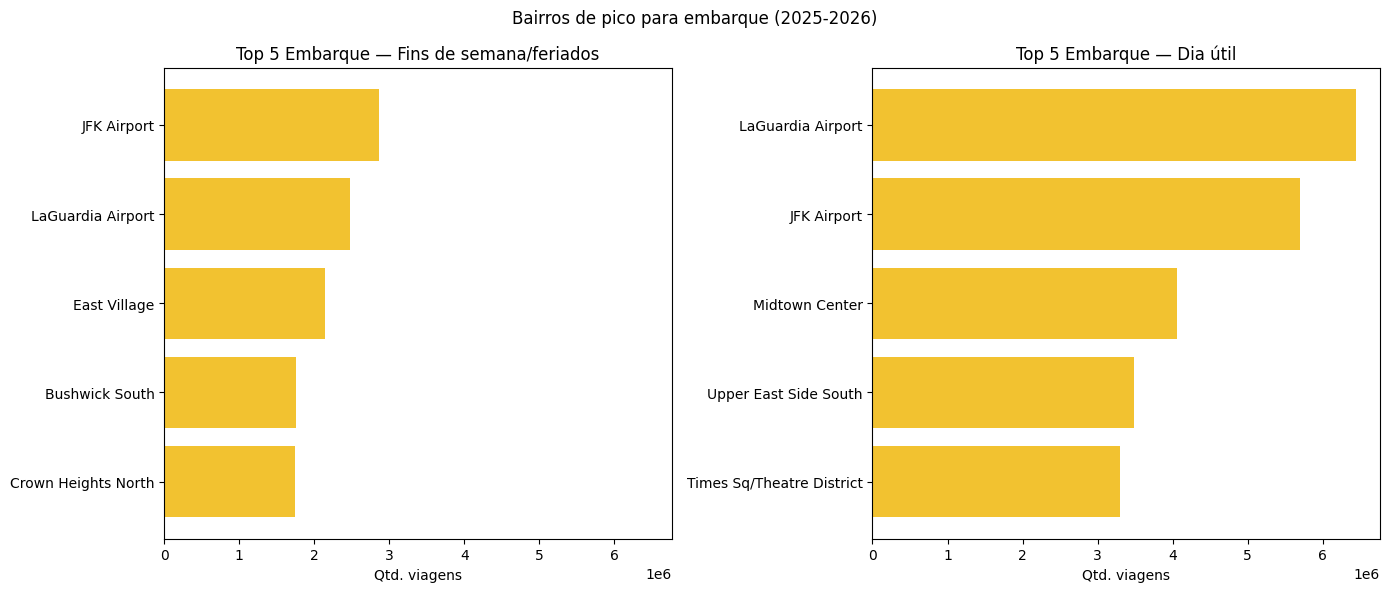

In [0]:
import matplotlib.pyplot as plt

pdf_pickup = _sqldf.toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

for ax, flag in zip(axes, pdf_pickup["Fl_Dia_Util"].unique()):
    subset = pdf_pickup[pdf_pickup["Fl_Dia_Util"] == flag].sort_values("Qtd_Viagens")
    ax.barh(subset["Bairro"], subset["Qtd_Viagens"], color="#F2C230")
    ax.set_title(f"Top 5 Embarque — {"Dia útil" if flag else "Fins de semana/feriados"}")
    ax.set_xlabel("Qtd. viagens")

plt.suptitle("Bairros de pico para embarque (2025-2026)")
plt.tight_layout()
plt.show()

Os cinco principais bairros e locais de embarque, em ordem decrescente de demanda, são:

**Em fins de semana e feriados:**

1. Aeroporto JFK
2. Aeroporto de LaGuardia
3. East Village
4. Bushwick South
5. Crown Heights

**Em dias úteis:**

1. Aeroporto de LaGuardia
2. Aeroporto JFK
3. Midtown Center
4. Upper East Side South
5. Times Sq/Theatre District

Observou-se que há variação entre os bairros mais demandados nos dois tipos de dia e que o volume de viagens é menor nos fins de semana, o que indica um menor fluxo de pessoas no interior da cidade e também de deslocamentos de e para fora dela.

In [0]:
%sql
WITH base_Desembarque AS (
    SELECT
        c.Fl_Dia_Util,
        z.Zona AS Bairro,
        SUM(f.Qtd_Viagens) AS Qtd_Viagens
    FROM fato_demanda_horaria f
    JOIN dim_calendario c ON f.Data_Destino = c.Data
    JOIN dim_zonas_de_taxi z ON f.ID_Destino = z.IDLocal
    WHERE c.Ano >= 2025
    GROUP BY c.Fl_Dia_Util, z.Zona
),
rank_Desembarque AS (
    SELECT
        *,
        ROW_NUMBER() OVER (PARTITION BY Fl_Dia_Util ORDER BY Qtd_Viagens DESC) AS Rank_Desembarque
    FROM base_Desembarque
)
SELECT * FROM rank_Desembarque WHERE Rank_Desembarque <= 5
ORDER BY Fl_Dia_Util, Rank_Desembarque

Fl_Dia_Util,Bairro,Qtd_Viagens,Rank_Desembarque
false,Outside of NYC,5726416,1
false,JFK Airport,2486256,2
false,LaGuardia Airport,2250574,3
false,Crown Heights North,1884849,4
false,Bushwick South,1727772,5
true,Outside of NYC,10987351,1
true,LaGuardia Airport,6094758,2
true,JFK Airport,5384465,3
true,Midtown Center,3266595,4
true,Upper East Side North,3165342,5


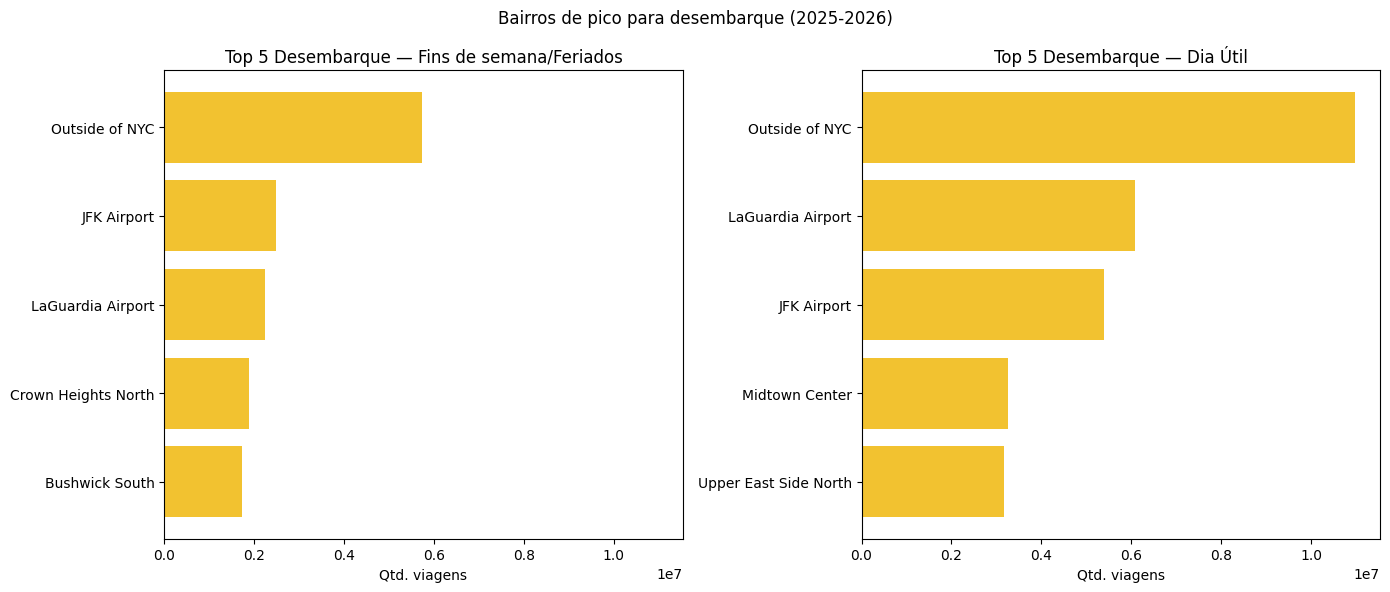

In [0]:
pdf_dropoff = _sqldf.toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

for ax, flag in zip(axes, pdf_dropoff["Fl_Dia_Util"].unique()):
    subset = pdf_dropoff[pdf_dropoff["Fl_Dia_Util"] == flag].sort_values("Qtd_Viagens")
    ax.barh(subset["Bairro"], subset["Qtd_Viagens"], color="#F2C230")
    ax.set_title(f"Top 5 Desembarque — {'Dia Útil' if flag else 'Fins de semana/Feriados'}")
    ax.set_xlabel("Qtd. viagens")

plt.suptitle("Bairros de pico para desembarque (2025-2026)")
plt.tight_layout()
plt.show()

Para desembarque, os principais bairros/locais em fins de semana e feriados são, respectivamente:
```
* Local fora da cidade
* Aeroport JFK
* Aeroporto LaGuardia
* Crown Heights North
* Bushwick South
```
Nos dias uteis são:
```
* Local fora da cidade
* Aeroporto de LaGuardia
* Aeroporto JFK
* Midtown Center
* Upper East Side North
```

O principal destino de desembarque em Nova Iorque é um local fora da cidade, indicando o alto fluxo de pessoas.

In [0]:
%sql
SELECT
    c.Nm_Mes,
    c.Nr_Mes,
    c.Fl_Dia_Util,  -- ou derive: CASE WHEN dayofweek(c.Data) IN (1,7) THEN 'Não útil' ELSE 'Útil' END
    f.Hora_Embarque,  -- se sua fato tiver granularidade horária; senão precisa vir de outra fato
    SUM(f.Qtd_Viagens) AS Qtd_Viagens
FROM fato_demanda_horaria f
JOIN dim_calendario c ON f.Data_Embarque = c.Data
GROUP BY c.Nm_Mes, c.Fl_Dia_Util, f.Hora_Embarque, c.Nr_Mes
ORDER BY c.Nr_Mes, c.Fl_Dia_Util, f.Hora_Embarque

Nm_Mes,Nr_Mes,Fl_Dia_Util,Hora_Embarque,Qtd_Viagens
January,1,false,0,7876634
January,1,false,1,5624875
January,1,false,2,4186851
January,1,false,3,3263513
January,1,false,4,2983839
January,1,false,5,3382844
January,1,false,6,5703764
January,1,false,7,9196338
January,1,false,8,11389102
January,1,false,9,10699623


6 - Quais são os horários de pico, para embarque e desembarque, por distrito, em dias úteis e não úteis?

In [0]:
%sql
WITH base_pickup AS (
    SELECT
        z.Distrito,
        c.Fl_Dia_Util,
        f.Hora_Embarque AS Hora,
        SUM(f.Qtd_Viagens) AS Qtd_Viagens
    FROM fato_demanda_horaria f
    JOIN dim_calendario c ON f.Data_Embarque = c.Data
    JOIN dim_zonas_de_taxi z ON f.ID_Embarque = z.IDLocal
    GROUP BY z.Distrito, c.Fl_Dia_Util, f.Hora_Embarque
)
SELECT * FROM base_pickup
ORDER BY Distrito, Fl_Dia_Util, Hora

Distrito,Fl_Dia_Util,Hora,Qtd_Viagens
Bronx,false,0,3801839
Bronx,false,1,2915055
Bronx,false,2,2165265
Bronx,false,3,1739052
Bronx,false,4,1522993
Bronx,false,5,1487225
Bronx,false,6,1879669
Bronx,false,7,2441928
Bronx,false,8,2763432
Bronx,false,9,3050209


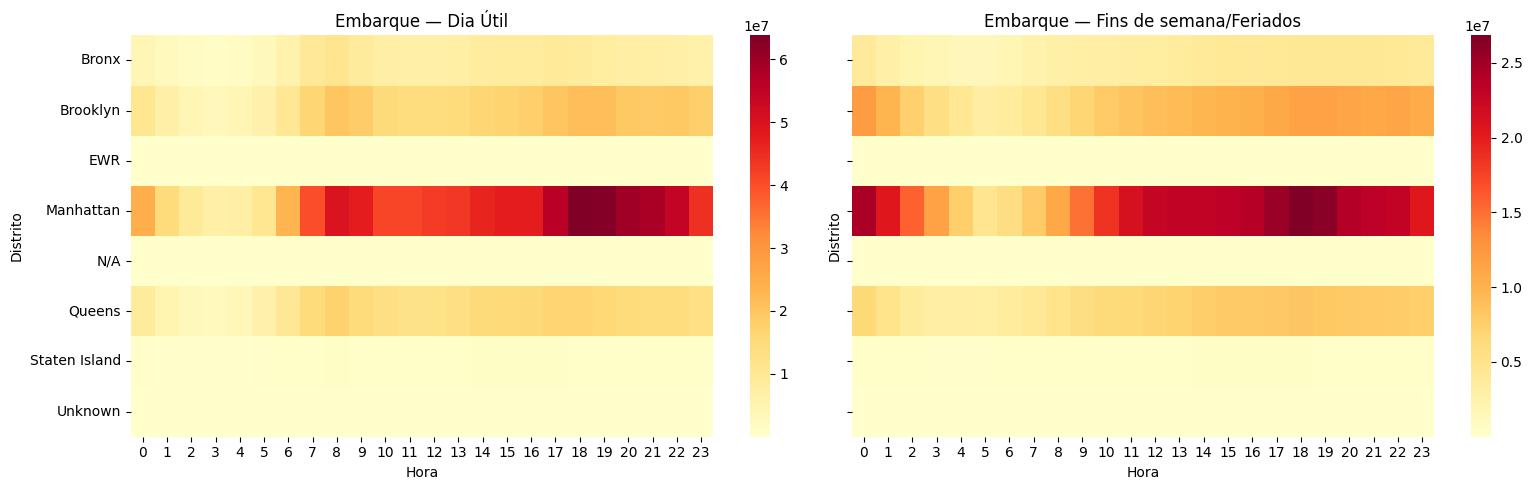

In [0]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, flag in zip(axes, [True, False]):
    subset = pdf_pickup[pdf_pickup["Fl_Dia_Util"] == flag]
    pivot_heat = subset.pivot(index="Distrito", columns="Hora", values="Qtd_Viagens")
    sns.heatmap(pivot_heat, cmap="YlOrRd", ax=ax, cbar=True)
    ax.set_title(f"Embarque — {'Dia Útil' if flag else 'Fins de semana/Feriados'}")

plt.tight_layout()
plt.show()

In [0]:
%sql
WITH base_dropoff AS (
    SELECT
        z.Distrito,
        c.Fl_Dia_Util,
        f.Hora_Embarque AS Hora,
        SUM(f.Qtd_Viagens) AS Qtd_Viagens
    FROM fato_demanda_horaria f
    JOIN dim_calendario c ON f.Data_Destino = c.Data
    JOIN dim_zonas_de_taxi z ON f.ID_Destino = z.IDLocal
    GROUP BY z.Distrito, c.Fl_Dia_Util, f.Hora_Embarque
)
SELECT * FROM base_dropoff
ORDER BY Distrito, Fl_Dia_Util, Hora

Distrito,Fl_Dia_Util,Hora,Qtd_Viagens
Bronx,false,0,4165963
Bronx,false,1,3268359
Bronx,false,2,2498279
Bronx,false,3,1993645
Bronx,false,4,1646599
Bronx,false,5,1269271
Bronx,false,6,1476483
Bronx,false,7,2017301
Bronx,false,8,2314006
Bronx,false,9,2540172


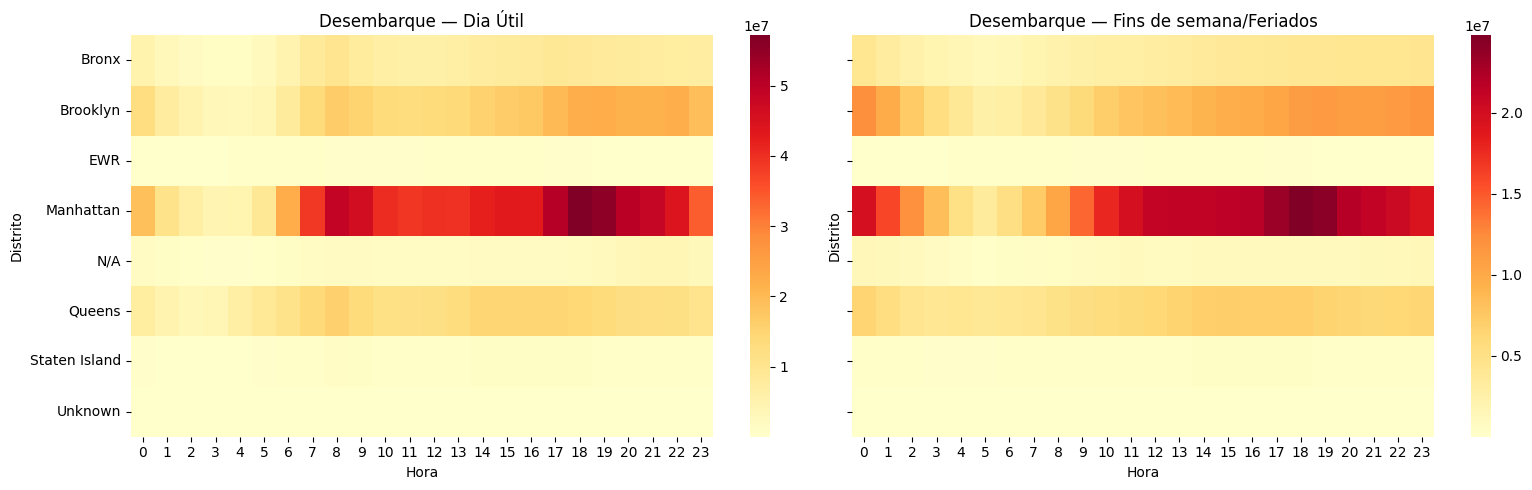

In [0]:
import seaborn as sns

pdf_dropoff = _sqldf.toPandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, flag in zip(axes, [True, False]):
    subset = pdf_dropoff[pdf_dropoff["Fl_Dia_Util"] == flag]
    pivot_heat = subset.pivot(index="Distrito", columns="Hora", values="Qtd_Viagens")
    sns.heatmap(pivot_heat, cmap="YlOrRd", ax=ax, cbar=True)
    ax.set_title(f"Desembarque — {'Dia Útil' if flag else 'Fins de semana/Feriados'}")

plt.tight_layout()
plt.show()

O distrito de Manhattan é, de longe, o local com maior fluxo de pessoas embarcando em toda a cidade, independentemente do período ser dia últil ou feriado/finais de semana. Pela leitura do gráfico, observase que o fluxo de carros é intenso a partir 6-7 da manhã, atingindo um pico entre as 18-19 horas da noite, e decrescendo nas horas seguintes. Nos finais de semana e feriados a demanda por embarque de veículos continua alta até meados de 2 horas da manhã.
A demanda por embarques nos outros distritos é insignificante, de acordo com a escala gráfica

8 - Como as tarifas base ao passageiro (sem incluir impostos, gorjetas e taxas) tem acompanhado a inflação geral americana, e a inflação especifica do segmento de transportes? As regulamentações do setor taxista fazem com que ela tenha sofrido menos ou mais reajustes na inflação com relação a corridas por aplicativo?

In [0]:
%sql
WITH remuneracao_mensal AS (
    SELECT
        TRUNC( f.Data , 'MM' ) AS Data,
        SUM(f.Remuneracao_Motorista) / SUM(f.Qtd_Viagens) AS Remuneracao_Media_Viagem
    FROM fato_corrida_mensal f
    JOIN dim_tipo_veiculo v ON f.ID_Veiculo = v.ID_Veiculo
    WHERE v.Categoria = 'For Hire Service'
        AND f.Data >= '2019-02-01'
    GROUP BY f.Data
),
base_2019 AS (
    -- pega o primeiro mês como referência para normalizar em base 100
    SELECT Remuneracao_Media_Viagem AS Valor_Base
    FROM remuneracao_mensal
    ORDER BY Data
    LIMIT 1
),
cpi_2019 AS (
    SELECT Indice_CPI_U AS CPI_Base
    FROM fato_inflacao_cpi
    WHERE Data >= '2019-02-01'
    ORDER BY Data
    LIMIT 1
)
SELECT
    r.Data,
    r.Remuneracao_Media_Viagem,
    100.0 * r.Remuneracao_Media_Viagem / b.Valor_Base AS Remuneracao_Indexada,
    i.Indice_CPI_U,
    100.0 * i.Indice_CPI_U / c.CPI_Base AS CPI_Indexado
FROM remuneracao_mensal r
JOIN fato_inflacao_cpi i ON r.Data = i.Data
CROSS JOIN base_2019 b
CROSS JOIN cpi_2019 c
ORDER BY r.Data

Data,Remuneracao_Media_Viagem,Remuneracao_Indexada,Indice_CPI_U,CPI_Indexado
2019-02-01,14.320037212811115427,100.000000,253.319,100.0
2019-03-01,15.012507125053889026,104.835671,254.277,100.37817929172307
2019-04-01,15.140412697067932449,105.728864,255.233,100.75556906509185
2019-05-01,16.164983122072908692,112.883667,255.296,100.78043889325318
2019-06-01,16.199785825998828357,113.126702,255.213,100.74767388154856
2019-07-01,15.019050590925781031,104.881366,255.802,100.98018703689814
2019-08-01,13.550384854864776302,94.625347,256.036,101.07256068435451
2019-09-01,15.559026363831733232,108.652136,256.43,101.22809580015712
2019-10-01,14.834060494952951232,103.589539,257.155,101.51429620360098
2019-11-01,14.656561890319890215,102.350027,257.879,101.80010184786772


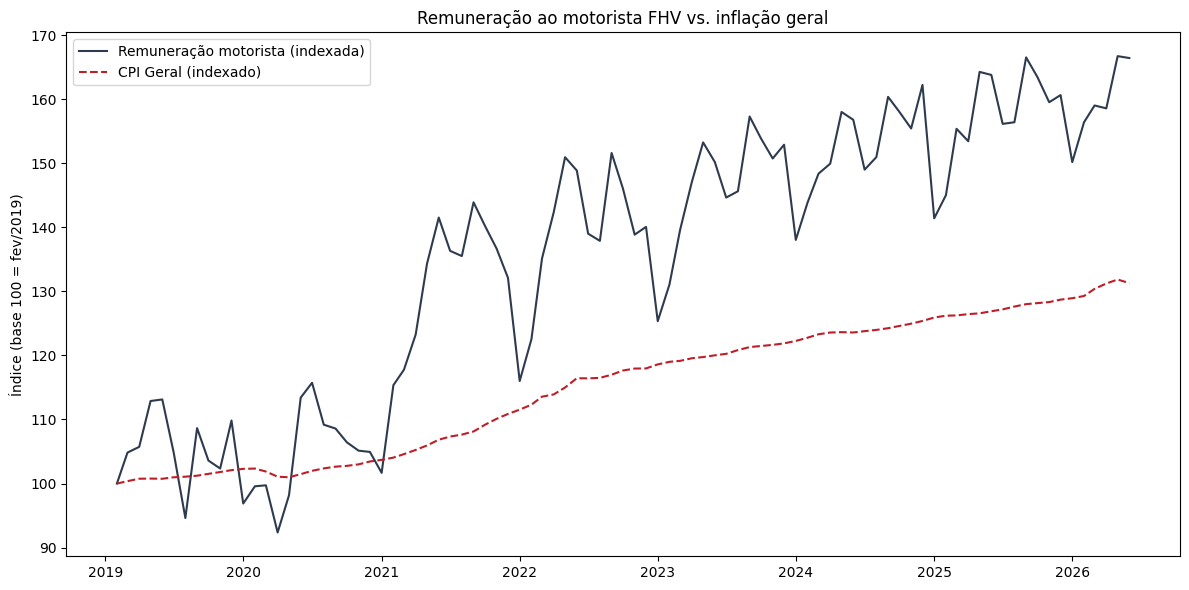

In [0]:
pdf_rem = _sqldf.toPandas()

fig, ax = plt.subplots(figsize=(12,6))
ax.plot(pdf_rem["Data"], pdf_rem["Remuneracao_Indexada"], label="Remuneração motorista (indexada)", color="#2E3B4E")
ax.plot(pdf_rem["Data"], pdf_rem["CPI_Indexado"], label="CPI Geral (indexado)", color="#BE1E28", linestyle="--")
ax.set_ylabel("Índice (base 100 = fev/2019)")
ax.legend()
ax.set_title("Remuneração ao motorista FHV vs. inflação geral")
plt.tight_layout()
plt.show()

In [0]:
%sql
WITH tarifa_mensal AS (
    SELECT
        TRUNC( f.Data, 'MM' ) AS Data,
        v.Categoria,
        SUM(f.Tarifa_Base) / SUM(f.Qtd_Viagens) AS Tarifa_Media_Viagem
    FROM fato_corrida_mensal f
    JOIN dim_tipo_veiculo v ON f.ID_Veiculo = v.ID_Veiculo
    WHERE f.Data >= '2019-02-01'
    GROUP BY f.Data, v.Categoria
),
base_valores AS (
    -- valor base (jan/2019) por categoria, via window function
    SELECT
        Categoria,
        FIRST_VALUE(Tarifa_Media_Viagem) OVER (PARTITION BY Categoria ORDER BY Data) AS Valor_Base
    FROM tarifa_mensal
),
cpi_base AS (
    SELECT
        FIRST_VALUE(Indice_CPI_U) OVER (ORDER BY Data) AS CPI_U_Base,
        FIRST_VALUE(Indice_CPI_T) OVER (ORDER BY Data) AS CPI_T_Base,
        Data
    FROM fato_inflacao_cpi
    WHERE Data >= '2019-02-01'
)
SELECT DISTINCT
    t.Data,
    t.Categoria,
    t.Tarifa_Media_Viagem,
    100.0 * t.Tarifa_Media_Viagem / b.Valor_Base AS Tarifa_Indexada,
    i.Indice_CPI_U,
    i.Indice_CPI_T,
    100.0 * i.Indice_CPI_U / cb.CPI_U_Base AS CPI_U_Indexado,
    100.0 * i.Indice_CPI_T / cb.CPI_T_Base AS CPI_T_Indexado
FROM tarifa_mensal t
JOIN base_valores b ON t.Categoria = b.Categoria
JOIN fato_inflacao_cpi i ON t.Data = i.Data
JOIN cpi_base cb ON t.Data = cb.Data
ORDER BY t.Categoria, t.Data

Data,Categoria,Tarifa_Media_Viagem,Tarifa_Indexada,Indice_CPI_U,Indice_CPI_T,CPI_U_Indexado,CPI_T_Indexado
2019-02-01,For Hire Service,15.762761439004915503,100.000000,253.319,207.495,100.0,100.0
2019-03-01,For Hire Service,15.458968920884375399,98.072720,254.277,210.097,100.37817929172307,101.25400612062941
2019-04-01,For Hire Service,16.295258253779338204,103.378195,255.233,213.037,100.75556906509185,102.67090773271646
2019-05-01,For Hire Service,17.777110341674885180,112.779163,255.296,211.761,100.78043889325318,102.05595315549772
2019-06-01,For Hire Service,18.582643248680239059,117.889517,255.213,209.25,100.74767388154856,100.84580351333767
2019-07-01,For Hire Service,17.147799263473564261,108.786771,255.802,209.934,100.98018703689814,101.17545001084363
2019-08-01,For Hire Service,15.870570638992053053,100.683949,256.036,209.27,101.07256068435451,100.85544229981446
2019-09-01,For Hire Service,18.357987289870780336,116.464284,256.43,209.085,101.22809580015712,100.76628352490421
2019-10-01,For Hire Service,18.242602722076159486,115.732277,257.155,210.25,101.51429620360098,101.3277428371768
2019-11-01,For Hire Service,17.240663762814918613,109.375910,257.879,211.286,101.80010184786772,101.82703197667412


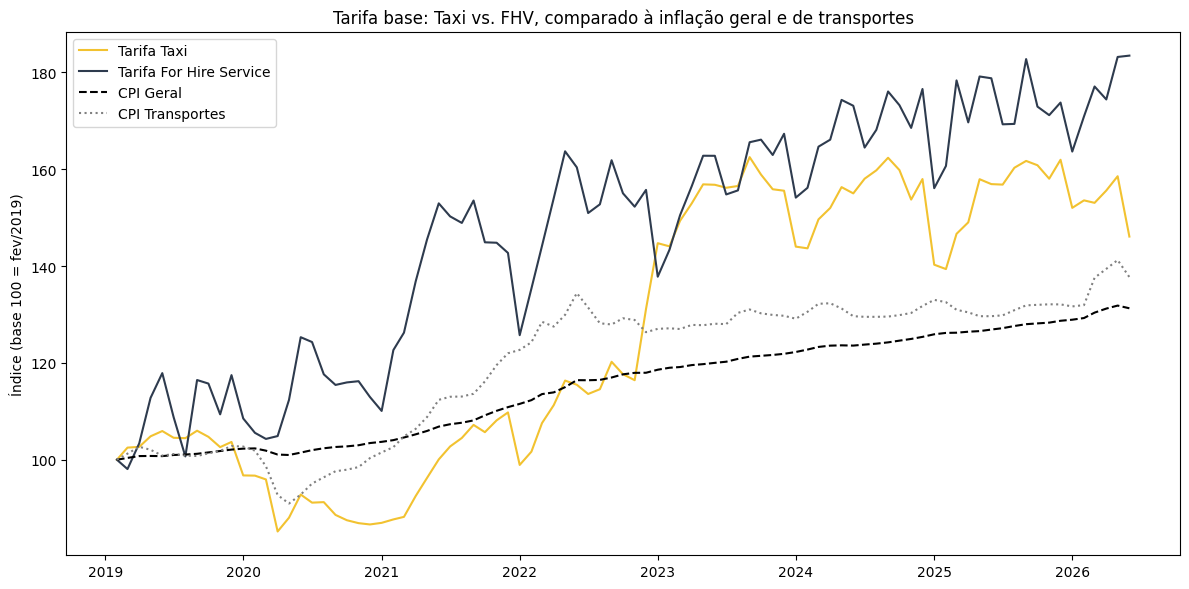

In [0]:
pdf_rem = _sqldf.toPandas()

fig, ax = plt.subplots(figsize=(12,6))

for categoria, cor in [("Taxi", "#F2C230"), ("For Hire Service", "#2E3B4E")]:
    subset = pdf_rem[pdf_rem["Categoria"] == categoria].sort_values("Data")
    ax.plot(subset["Data"], subset["Tarifa_Indexada"], label=f"Tarifa {categoria}", color=cor)

# CPI é igual pras duas categorias (mesma série), pega de qualquer uma
cpi_ref = pdf_rem[pdf_rem["Categoria"] == "Taxi"].sort_values("Data")
ax.plot(cpi_ref["Data"], cpi_ref["CPI_U_Indexado"], label="CPI Geral", color="black", linestyle="--")
ax.plot(cpi_ref["Data"], cpi_ref["CPI_T_Indexado"], label="CPI Transportes", color="gray", linestyle=":")

ax.set_ylabel("Índice (base 100 = fev/2019)")
ax.legend()
ax.set_title("Tarifa base: Taxi vs. FHV, comparado à inflação geral e de transportes")
plt.tight_layout()
plt.show()

In [0]:
variacao_final = pdf_rem.groupby("Categoria").apply(
    lambda g: g.sort_values("Data").iloc[-1]["Tarifa_Indexada"] - 100,
    include_groups=False
)
print(variacao_final)

Categoria
For Hire Service    83.469909
Taxi                46.096240
dtype: object


In [0]:
variacao_final = pdf_rem.groupby("Categoria").apply(
    lambda g: g.sort_values("Data").iloc[-1]["Tarifa_Indexada"] - 100,
    include_groups=False
)

cpi_final = cpi_ref.sort_values("Data").iloc[-1][["CPI_U_Indexado", "CPI_T_Indexado"]] - 100

In [0]:
for categoria, valor in variacao_final.items():
    print(f"{categoria}: +{valor:.1f} pontos desde fev/2019")
for categoria, valor in cpi_final.items():
    print(f"{categoria}: +{valor:.1f} pontos desde fev/2019")

For Hire Service: +83.5 pontos desde fev/2019
Taxi: +46.1 pontos desde fev/2019
CPI_U_Indexado: +31.3 pontos desde fev/2019
CPI_T_Indexado: +37.7 pontos desde fev/2019


Pode-se observar que a remuneração dos motoristas do segmento "For Hire Services" tem crescido significativamente mais que a inflação geral. Para comparativos, a remuneração dos motoristas cresceu 83,5% com relação ao baseline de fevereiro de 2019, versus uma inflação acumulada de 31,3%.

Já o custo de transportes de táxi tem crescido 46,1% no mesmo período, versus uma inflação do segmento de transportes de 37,7%.